# Credit Card Fraud Detection: Unsupervised Learning Analysis

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook accompanies the project **[Credit Card Fraud Detection](https://rodrigokang.github.io/portfolio/2-retail-analytics/1-credit-card-fraud-detection-ml-benchmark.html)** and contains the computational implementation supporting the methodology, experiments, and results discussed in the portfolio chapter.

The material presented here focuses on practical implementation details, including data preparation, model development, training procedures, evaluation workflows, and complementary computational experiments.

## Imports and Configuration

The following libraries are used for data manipulation, visualization, model development, performance evaluation, and benchmark execution.

In [1]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Numerical computing
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation metrics
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Reproducibility
random_state = 42

# Visualization settings
sns.set_theme(
    style="whitegrid"
)

## Data Loading

The dataset is loaded into memory and basic structural information is inspected before proceeding with data preparation.

In [2]:
# Load dataset
df = pd.read_csv(
    "../data/creditcard.csv"
)

# Display dataset dimensions
print(
    f"Dataset shape: {df.shape}"
)

Dataset shape: (284807, 31)


## Data Preparation

The feature matrix and target variable are defined. The dataset is then partitioned into training and testing subsets using a stratified split to preserve the original class distribution. Finally, the predictors are standardized using statistics estimated from the training set.

In [3]:
# Define predictors and target
X = df.drop(
    columns="Class"
)

y = df["Class"]

In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=random_state
)

print(
    f"Training observations: {X_train.shape[0]}"
)

print(
    f"Testing observations: {X_test.shape[0]}"
)

Training observations: 227845
Testing observations: 56962


In [5]:
# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

## Supervised Learning Benchmark

This section evaluates a set of supervised classification algorithms for credit card fraud detection. The benchmark first uses the original class distribution and then compares alternative strategies for handling class imbalance.

### Cross-Validation Strategy

Stratified cross-validation is used to preserve the original class distribution within each fold. This is particularly important because fraudulent transactions represent only a very small fraction of the dataset.

In [6]:
# Define cross-validation strategy
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=random_state
)

### Performance Metrics

The benchmark uses metrics that are informative under severe class imbalance. Precision, recall, and F1-score summarize classification performance, while ROC-AUC and Precision-Recall AUC evaluate ranking quality.

In [7]:
# Define scoring metrics
scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}

### Benchmark Models

The benchmark includes linear, probabilistic, discriminant, distance-based, margin-based, tree-based, ensemble, and gradient boosting classifiers. Linear SVM is used instead of kernel-based SVC to keep the benchmark computationally tractable on the full training set.

In [9]:
# Define benchmark models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=random_state,
        max_iter=1000
    ),

    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),
    "Linear SVM": LinearSVC(
        random_state=random_state,
        max_iter=10000
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=random_state
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=random_state,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        random_state=random_state,
        eval_metric="logloss",
        n_jobs=-1
    )
}

### Benchmark 1: Original Class Distribution

The first benchmark evaluates all models using the original training distribution. No resampling technique is applied. This baseline reflects the natural class imbalance of the transaction data and provides a reference point for later comparisons.

In [10]:
# Evaluate models using the original class distribution
original_results = []

for model_name, model in models.items():

    cv_results = cross_validate(
        estimator=model,
        X=X_train_scaled,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    original_results.append({
        "benchmark": "Original",
        "model": model_name,
        "precision": np.mean(cv_results["test_precision"]),
        "recall": np.mean(cv_results["test_recall"]),
        "f1_score": np.mean(cv_results["test_f1"]),
        "roc_auc": np.mean(cv_results["test_roc_auc"]),
        "pr_auc": np.mean(cv_results["test_average_precision"])
    })

original_results = pd.DataFrame(original_results)

original_results.sort_values(
    "pr_auc",
    ascending=False
)

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
7,Original,Random Forest,0.946530,0.774067,0.850747,0.948841,0.840521
4,Original,KNN,0.932338,0.753781,0.833007,0.919893,0.799034
5,Original,Linear SVM,0.899244,0.616780,0.730032,0.968431,0.774572
0,Original,Logistic Regression,0.877294,0.637001,0.737104,0.978714,0.761864
2,Original,LDA,0.878622,0.761409,0.815061,0.980881,0.756450
3,Original,QDA,0.061370,0.868095,0.114632,0.974988,0.640911
8,Original,XGBoost,0.725425,0.612723,0.662322,0.829389,0.612429
6,Original,Decision Tree,0.775679,0.768971,0.771253,0.884290,0.596234
1,Original,Naive Bayes,0.061449,0.824927,0.114368,0.960735,0.086708


The original benchmark provides the baseline performance of each classifier under the natural class imbalance of the dataset. Subsequent benchmarks will compare these results against models trained with resampling strategies.

### Benchmark 2: Random Undersampling

The second benchmark applies random undersampling to the majority class before model training. Legitimate transactions are randomly removed until both classes contain the same number of observations.

The objective is to evaluate whether reducing class imbalance improves the ability of the models to identify fraudulent transactions.

In [12]:
# Random undersampling
from imblearn.under_sampling import RandomUnderSampler

undersampler = RandomUnderSampler(
    random_state=random_state
)

X_train_under, y_train_under = (
    undersampler.fit_resample(
        X_train_scaled,
        y_train
    )
)

In [13]:
# Inspect undersampled dataset
print(
    "Class distribution after undersampling:"
)

print(
    y_train_under.value_counts()
)

Class distribution after undersampling:
Class
0    394
1    394
Name: count, dtype: int64


The resulting dataset contains the same number of legitimate and fraudulent transactions. Although a substantial portion of the majority class is discarded, the balanced dataset may allow certain classifiers to learn fraud-related patterns more effectively.

In [16]:
# Compare class distributions
pd.DataFrame({
    "Original": y_train.value_counts(),
    "Undersampled": y_train_under.value_counts()
})

,Original,Undersampled
Class,,
0,227451,394
1,394,394


### Model Evaluation

The benchmark models are evaluated using the undersampled training set and the same cross-validation strategy employed in the original benchmark. This ensures that performance differences can be attributed to the imbalance treatment rather than to changes in the evaluation procedure.

In [17]:
# Evaluate models using the undersampled dataset
undersampling_results = []

for model_name, model in models.items():

    cv_results = cross_validate(
        estimator=model,
        X=X_train_under,
        y=y_train_under,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    undersampling_results.append({
        "benchmark": "Undersampling",
        "model": model_name,
        "precision": np.mean(
            cv_results["test_precision"]
        ),
        "recall": np.mean(
            cv_results["test_recall"]
        ),
        "f1_score": np.mean(
            cv_results["test_f1"]
        ),
        "roc_auc": np.mean(
            cv_results["test_roc_auc"]
        ),
        "pr_auc": np.mean(
            cv_results["test_average_precision"]
        )
    })

undersampling_results = pd.DataFrame(
    undersampling_results
)

undersampling_results.sort_values(
    "pr_auc",
    ascending=False
)

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
8,Undersampling,XGBoost,0.974722,0.928952,0.950665,0.981113,0.986659
7,Undersampling,Random Forest,0.980737,0.903603,0.940424,0.979657,0.984247
0,Undersampling,Logistic Regression,0.967958,0.911230,0.938443,0.977177,0.983172
5,Undersampling,Linear SVM,0.971248,0.921357,0.945207,0.976572,0.982987
3,Undersampling,QDA,0.941707,0.898507,0.919503,0.974782,0.980184
2,Undersampling,LDA,0.982499,0.832522,0.900401,0.967635,0.974766
4,Undersampling,KNN,0.988990,0.893444,0.938340,0.967429,0.967199
1,Undersampling,Naive Bayes,0.963428,0.868095,0.913058,0.959784,0.957926
6,Undersampling,Decision Tree,0.910007,0.939111,0.923906,0.922606,0.885080


### Benchmark 3: Synthetic Minority Oversampling Technique (SMOTE)

The third benchmark applies the Synthetic Minority Oversampling Technique (SMOTE) to the training data. Unlike random undersampling, which removes observations from the majority class, SMOTE generates synthetic examples of the minority class.

The objective is to determine whether synthetic oversampling can improve fraud detection performance while preserving the information contained in the original majority class.

In [19]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=random_state
)

X_train_smote, y_train_smote = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

In [20]:
# Inspect SMOTE dataset
print(
    "Class distribution after SMOTE:"
)

print(
    y_train_smote.value_counts()
)

Class distribution after SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


The resulting dataset contains an equal number of legitimate and fraudulent transactions. Unlike random undersampling, no legitimate observations are discarded. Instead, synthetic fraud examples are generated from the existing minority class observations.

In [21]:
# Compare class distributions
pd.DataFrame({
    "Original": y_train.value_counts(),
    "Undersampled": y_train_under.value_counts(),
    "SMOTE": y_train_smote.value_counts()
})

,Original,Undersampled,SMOTE
Class,,,
0,227451,394,227451
1,394,394,227451


### Model Evaluation

The benchmark models are evaluated using the SMOTE dataset and the same cross-validation procedure employed in the previous benchmarks.

In [22]:
# Evaluate models using the SMOTE dataset
smote_results = []

for model_name, model in models.items():

    cv_results = cross_validate(
        estimator=model,
        X=X_train_smote,
        y=y_train_smote,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    smote_results.append({
        "benchmark": "SMOTE",
        "model": model_name,
        "precision": np.mean(
            cv_results["test_precision"]
        ),
        "recall": np.mean(
            cv_results["test_recall"]
        ),
        "f1_score": np.mean(
            cv_results["test_f1"]
        ),
        "roc_auc": np.mean(
            cv_results["test_roc_auc"]
        ),
        "pr_auc": np.mean(
            cv_results["test_average_precision"]
        )
    })

smote_results = pd.DataFrame(
    smote_results
)

smote_results.sort_values(
    "pr_auc",
    ascending=False
)

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
8,SMOTE,XGBoost,0.999517,1.000000,0.999758,0.999987,0.999984
7,SMOTE,Random Forest,0.999815,0.999996,0.999905,0.999990,0.999981
4,SMOTE,KNN,0.997881,1.000000,0.998939,0.999686,0.999372
6,SMOTE,Decision Tree,0.997007,0.998866,0.997936,0.997934,0.996443
0,SMOTE,Logistic Regression,0.973106,0.930460,0.951305,0.991591,0.992457
5,SMOTE,Linear SVM,0.976541,0.916162,0.945388,0.990700,0.991674
3,SMOTE,QDA,0.970945,0.890201,0.928821,0.982706,0.986390
2,SMOTE,LDA,0.983867,0.849444,0.911727,0.981016,0.981573
1,SMOTE,Naive Bayes,0.972497,0.848161,0.906083,0.949566,0.954713


## Benchmark Comparison

The three benchmarks represent different approaches to the class imbalance problem. The original distribution preserves the natural transaction frequencies, random undersampling balances the classes by removing majority observations, and SMOTE balances the classes by generating synthetic minority examples.

The following comparison summarizes the average cross-validation performance obtained under each benchmark configuration.

In [24]:
# Combine benchmark results
benchmark_results = pd.concat(
    [
        original_results,
        undersampling_results,
        smote_results
    ],
    ignore_index=True
)

benchmark_results

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
0,Original,Logistic Regression,0.877294,0.637001,0.737104,0.978714,0.761864
1,Original,Naive Bayes,0.061449,0.824927,0.114368,0.960735,0.086708
2,Original,LDA,0.878622,0.761409,0.815061,0.980881,0.756450
3,Original,QDA,0.061370,0.868095,0.114632,0.974988,0.640911
4,Original,KNN,0.932338,0.753781,0.833007,0.919893,0.799034
5,Original,Linear SVM,0.899244,0.616780,0.730032,0.968431,0.774572
6,Original,Decision Tree,0.775679,0.768971,0.771253,0.884290,0.596234
7,Original,Random Forest,0.946530,0.774067,0.850747,0.948841,0.840521
8,Original,XGBoost,0.725425,0.612723,0.662322,0.829389,0.612429
9,Undersampling,Logistic Regression,0.967958,0.911230,0.938443,0.977177,0.983172


In [25]:
# Sort results by benchmark and PR-AUC
benchmark_results.sort_values(
    ["benchmark", "pr_auc"],
    ascending=[True, False]
)

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
7,Original,Random Forest,0.946530,0.774067,0.850747,0.948841,0.840521
4,Original,KNN,0.932338,0.753781,0.833007,0.919893,0.799034
5,Original,Linear SVM,0.899244,0.616780,0.730032,0.968431,0.774572
0,Original,Logistic Regression,0.877294,0.637001,0.737104,0.978714,0.761864
2,Original,LDA,0.878622,0.761409,0.815061,0.980881,0.756450
3,Original,QDA,0.061370,0.868095,0.114632,0.974988,0.640911
8,Original,XGBoost,0.725425,0.612723,0.662322,0.829389,0.612429
6,Original,Decision Tree,0.775679,0.768971,0.771253,0.884290,0.596234
1,Original,Naive Bayes,0.061449,0.824927,0.114368,0.960735,0.086708
26,SMOTE,XGBoost,0.999517,1.000000,0.999758,0.999987,0.999984


In [27]:
# Best model from each benchmark
best_models = (
    benchmark_results
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .groupby(
        "benchmark",
        as_index=False
    )
    .first()
)

best_models

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
0,Original,Random Forest,0.946530,0.774067,0.850747,0.948841,0.840521
1,SMOTE,XGBoost,0.999517,1.000000,0.999758,0.999987,0.999984
2,Undersampling,XGBoost,0.974722,0.928952,0.950665,0.981113,0.986659


## Final Evaluation on the Test Set

Cross-validation provides an estimate of model performance under different imbalance treatments. However, the ultimate objective is to assess how well the models generalize to unseen transactions.

The best-performing model from each benchmark is therefore retrained on its corresponding training dataset and evaluated on the original test set.

### Best Models from Each Benchmark

The highest-performing model from each benchmark is selected for final evaluation on the test set.

This comparison aims to determine whether improvements observed during cross-validation translate into superior performance on unseen transactions.

In [28]:
# Best model from each benchmark
best_models = (
    benchmark_results
    .sort_values(
        "pr_auc",
        ascending=False
    )
    .groupby(
        "benchmark",
        as_index=False
    )
    .first()
)

best_models

,benchmark,model,precision,recall,f1_score,roc_auc,pr_auc
0,Original,Random Forest,0.946530,0.774067,0.850747,0.948841,0.840521
1,SMOTE,XGBoost,0.999517,1.000000,0.999758,0.999987,0.999984
2,Undersampling,XGBoost,0.974722,0.928952,0.950665,0.981113,0.986659


### Model Training

Each selected model is retrained using its corresponding training dataset and then evaluated on the original test set.

In [29]:
# Original benchmark winner
rf_original = RandomForestClassifier(
    n_estimators=100,
    random_state=random_state,
    n_jobs=-1
)

rf_original.fit(
    X_train_scaled,
    y_train
)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [30]:
# Undersampling benchmark winner
xgb_under = XGBClassifier(
    n_estimators=100,
    random_state=random_state,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_under.fit(
    X_train_under,
    y_train_under
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [31]:
# SMOTE benchmark winner
xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=random_state,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

### Test Set Predictions

Predictions and probability scores are generated for the original test set. These outputs are used to compute evaluation metrics and diagnostic visualizations.

In [32]:
# Random Forest (Original)
rf_original_pred = rf_original.predict(
    X_test_scaled
)

rf_original_prob = rf_original.predict_proba(
    X_test_scaled
)[:, 1]

In [33]:
# XGBoost (Undersampling)
xgb_under_pred = xgb_under.predict(
    X_test_scaled
)

xgb_under_prob = xgb_under.predict_proba(
    X_test_scaled
)[:, 1]

In [34]:
# XGBoost (SMOTE)
xgb_smote_pred = xgb_smote.predict(
    X_test_scaled
)

xgb_smote_prob = xgb_smote.predict_proba(
    X_test_scaled
)[:, 1]

### Test Set Performance

The selected models are evaluated using the same metrics employed throughout the benchmark. Unlike the previous results, these metrics are computed on unseen data and therefore provide a direct estimate of real-world performance.

In [35]:
# Test set evaluation
test_results = pd.DataFrame({
    "model": [
        "Random Forest (Original)",
        "XGBoost (Undersampling)",
        "XGBoost (SMOTE)"
    ],

    "precision": [
        precision_score(y_test, rf_original_pred),
        precision_score(y_test, xgb_under_pred),
        precision_score(y_test, xgb_smote_pred)
    ],

    "recall": [
        recall_score(y_test, rf_original_pred),
        recall_score(y_test, xgb_under_pred),
        recall_score(y_test, xgb_smote_pred)
    ],

    "f1_score": [
        f1_score(y_test, rf_original_pred),
        f1_score(y_test, xgb_under_pred),
        f1_score(y_test, xgb_smote_pred)
    ],

    "roc_auc": [
        roc_auc_score(y_test, rf_original_prob),
        roc_auc_score(y_test, xgb_under_prob),
        roc_auc_score(y_test, xgb_smote_prob)
    ],

    "pr_auc": [
        average_precision_score(
            y_test,
            rf_original_prob
        ),

        average_precision_score(
            y_test,
            xgb_under_prob
        ),

        average_precision_score(
            y_test,
            xgb_smote_prob
        )
    ]
})

test_results.sort_values(
    "pr_auc",
    ascending=False
)

,model,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest (Original),0.941176,0.816327,0.874317,0.963027,0.873391
2,XGBoost (SMOTE),0.728070,0.846939,0.783019,0.979983,0.868282
1,XGBoost (Undersampling),0.033346,0.918367,0.064355,0.974863,0.374964


### Confusion Matrices

Confusion matrices provide a detailed view of classification outcomes by separating correct and incorrect predictions. They are particularly useful in fraud detection because they reveal the trade-off between missed fraud cases and false alarms.

In [36]:
# Compute confusion matrices
rf_cm = confusion_matrix(
    y_test,
    rf_original_pred
)

xgb_smote_cm = confusion_matrix(
    y_test,
    xgb_smote_pred
)

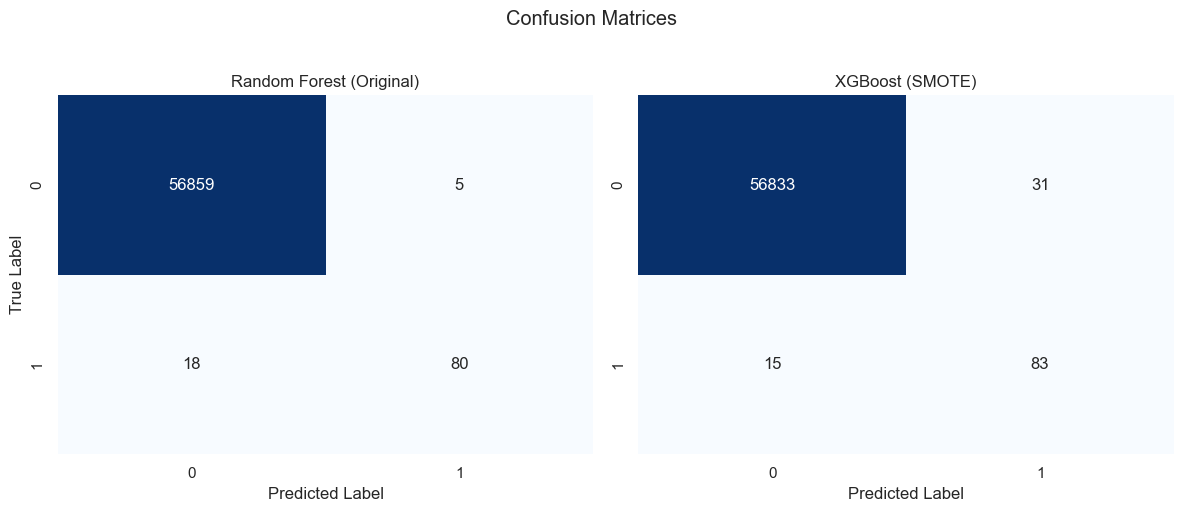

In [37]:
# Plot confusion matrices
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest (Original)"
)

axes[0].set_xlabel(
    "Predicted Label"
)

axes[0].set_ylabel(
    "True Label"
)

sns.heatmap(
    xgb_smote_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=axes[1]
)

axes[1].set_title(
    "XGBoost (SMOTE)"
)

axes[1].set_xlabel(
    "Predicted Label"
)

axes[1].set_ylabel("")

plt.suptitle(
    "Confusion Matrices",
    y=1.02
)

plt.tight_layout()

plt.show()

### Receiver Operating Characteristic (ROC) Curves

ROC curves illustrate the trade-off between the true positive rate and the false positive rate across different classification thresholds. The area under the curve (ROC-AUC) summarizes the ranking performance of the models.

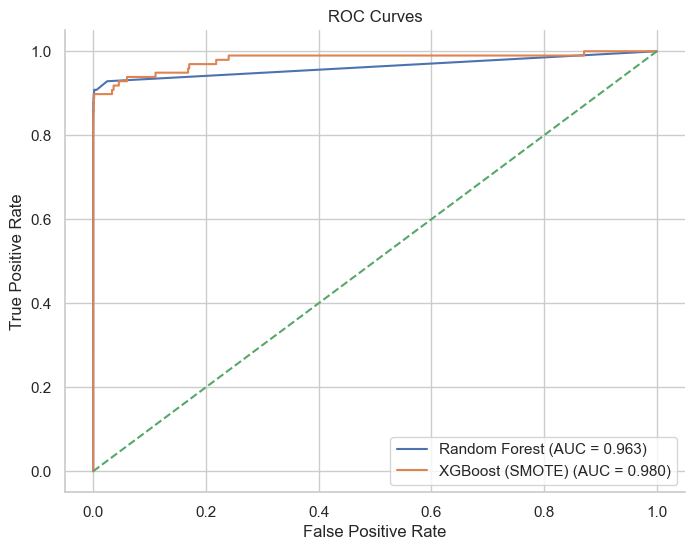

In [40]:
from sklearn.metrics import roc_curve

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_original_prob
)

xgb_fpr, xgb_tpr, _ = roc_curve(
    y_test,
    xgb_smote_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=(
        f"Random Forest "
        f"(AUC = {roc_auc_score(y_test, rf_original_prob):.3f})"
    )
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=(
        f"XGBoost (SMOTE) "
        f"(AUC = {roc_auc_score(y_test, xgb_smote_prob):.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curves"
)

plt.legend()
sns.despine()
plt.show()

### Precision-Recall Curves

Precision-Recall curves focus on the performance of the models with respect to the fraudulent class. Since fraudulent transactions represent only a small fraction of all observations, Precision-Recall curves often provide a more informative assessment than ROC curves.

In [41]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)

# Random Forest
rf_precision, rf_recall, _ = (
    precision_recall_curve(
        y_test,
        rf_original_prob
    )
)

# XGBoost (SMOTE)
xgb_precision, xgb_recall, _ = (
    precision_recall_curve(
        y_test,
        xgb_smote_prob
    )
)

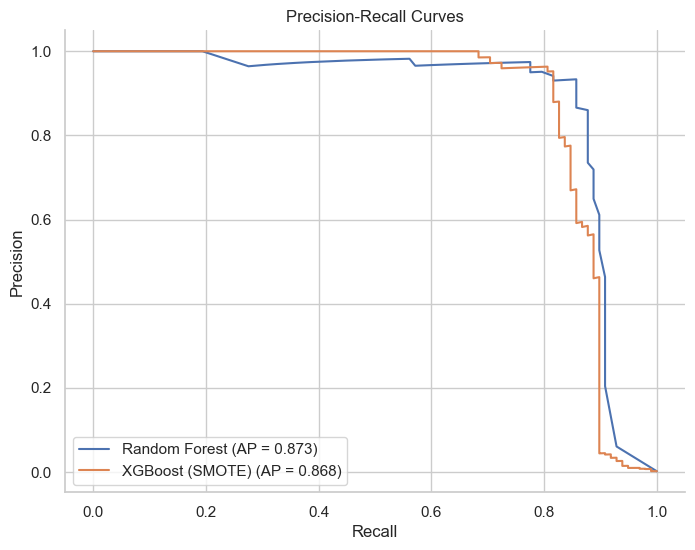

In [42]:
# Plot Precision-Recall curves
plt.figure(figsize=(8, 6))

plt.plot(
    rf_recall,
    rf_precision,
    label=(
        f"Random Forest "
        f"(AP = {average_precision_score(y_test, rf_original_prob):.3f})"
    )
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=(
        f"XGBoost (SMOTE) "
        f"(AP = {average_precision_score(y_test, xgb_smote_prob):.3f})"
    )
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curves"
)

plt.legend()

sns.despine()

plt.show()

### Kolmogorov-Smirnov Statistic

The Kolmogorov-Smirnov (KS) statistic measures the maximum separation between the cumulative distributions of fraudulent and legitimate transactions. Larger values indicate stronger discriminatory power.

In [43]:
from scipy.stats import ks_2samp

# Random Forest
rf_ks = ks_2samp(
    rf_original_prob[y_test == 0],
    rf_original_prob[y_test == 1]
).statistic

# XGBoost (SMOTE)
xgb_ks = ks_2samp(
    xgb_smote_prob[y_test == 0],
    xgb_smote_prob[y_test == 1]
).statistic

ks_results = pd.DataFrame({
    "Model": [
        "Random Forest (Original)",
        "XGBoost (SMOTE)"
    ],
    "KS Statistic": [
        rf_ks,
        xgb_ks
    ]
})

ks_results

,Model,KS Statistic
0,Random Forest (Original),0.906352
1,XGBoost (SMOTE),0.896165


## Discussion

The benchmark results highlight the importance of evaluating fraud detection models on realistic transaction distributions. Both undersampling and SMOTE substantially improved cross-validation metrics relative to the original dataset. However, these improvements did not consistently translate into superior performance on the independent test set.

Random undersampling produced very high recall but suffered from an extreme loss of precision when evaluated on unseen transactions. This suggests that balancing the classes by removing a large portion of legitimate transactions may distort the decision boundary and reduce generalization performance.

SMOTE achieved considerably stronger results than random undersampling and remained competitive across all evaluation metrics. Nevertheless, the best overall performance was obtained by Random Forest trained on the original class distribution. This model achieved the highest Precision-Recall AUC, the highest KS statistic, and the strongest balance between precision and recall on the test set.

These findings illustrate that improvements observed during resampling-based cross-validation should be interpreted cautiously. While resampling techniques can help mitigate class imbalance, preserving the original transaction distribution may lead to more robust models when the objective is to generalize to real-world fraud detection scenarios.

## Conclusions

This notebook evaluated a diverse set of supervised learning algorithms for credit card fraud detection under three different class imbalance strategies: the original transaction distribution, random undersampling, and SMOTE.

The benchmark demonstrated that class imbalance treatment can substantially influence model behavior. Random undersampling increased fraud detection rates but generated a large number of false positives when evaluated on unseen data. SMOTE provided a more effective alternative, producing strong classification performance while retaining information from the majority class.

Despite the strong cross-validation performance achieved by the resampling approaches, the best overall generalization performance was obtained by Random Forest trained on the original class distribution. This model achieved the highest Precision-Recall AUC and KS statistic on the test set while maintaining a favorable balance between fraud detection and false alarms.

The results suggest that resampling techniques should be viewed as complementary tools rather than automatic solutions to class imbalance. In this dataset, preserving the original transaction structure proved more effective than modifying the class distribution through undersampling or synthetic oversampling.